In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset

In [4]:
df_train = pd.read_csv('amazon_reviews/train_sub.csv')
df_test = pd.read_csv('amazon_reviews/test_sub.csv')

In [5]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 560000 entries, 0 to 559999
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  560000 non-null  int64
 1   label       560000 non-null  int64
 2   text        560000 non-null  str  
dtypes: int64(2), str(1)
memory usage: 12.8 MB


In [6]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 38000 entries, 0 to 37999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  38000 non-null  int64
 1   label       38000 non-null  int64
 2   text        38000 non-null  str  
dtypes: int64(2), str(1)
memory usage: 890.8 KB


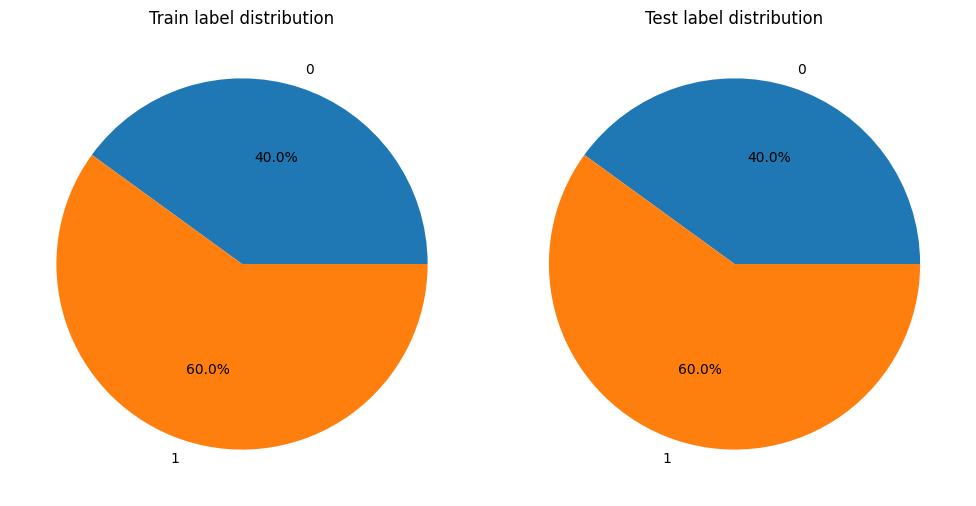

In [7]:
import matplotlib.pyplot as plt

# Count class distribution
train_counts = df_train['label'].value_counts().sort_index()
test_counts = df_test['label'].value_counts().sort_index()

# Create side-by-side pies
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].pie(train_counts, labels=train_counts.index, autopct='%1.1f%%')
axes[0].set_title('Train label distribution')

axes[1].pie(test_counts, labels=test_counts.index, autopct='%1.1f%%')
axes[1].set_title('Test label distribution')

plt.tight_layout()
plt.show()

# Preprocessing

In [8]:
import re

# regex obrasci
URL_RE = re.compile(r"http\S+|www\.\S+")
HTML_RE = re.compile(r"<.*?>")
WS_RE = re.compile(r"\s+")

def preprocess_text(text: str) -> str:
    text = str(text).lower()                 # lowercase
    text = URL_RE.sub(" ", text)             # remove URLs
    text = HTML_RE.sub(" ", text)            # remove HTML
    text = WS_RE.sub(" ", text).strip()      # remove extra spaces
    return text

In [9]:
df_train["text_clean"] = df_train["text"].map(preprocess_text)
df_test["text_clean"]  = df_test["text"].map(preprocess_text)

In [10]:
df_train[["text", "text_clean"]].head()

,text,text_clean
0,forget the movies this one is a clasic worth r...,forget the movies this one is a clasic worth r...
1,"If you're a fan of THE INVISIBLES, you have to...","if you're a fan of the invisibles, you have to..."
2,I personly think that the camara angles aren't...,i personly think that the camara angles aren't...
3,I know that miners were a tough breed but I ca...,i know that miners were a tough breed but i ca...
4,This is a great book that blends accurate acco...,this is a great book that blends accurate acco...


# TF-IDF

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stopwords = list(ENGLISH_STOP_WORDS - {"not", "no", "nor", "never"})

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=5,
    max_features=100000,
    stop_words=custom_stopwords,
    sublinear_tf=True
)

In [42]:
X_train = tfidf.fit_transform(df_train["text_clean"])
y_train = df_train["label"].astype(int).values

X_test  = tfidf.transform(df_test["text_clean"])
y_test  = df_test["label"].astype(int).values

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (560000, 100000) X_test: (38000, 100000)


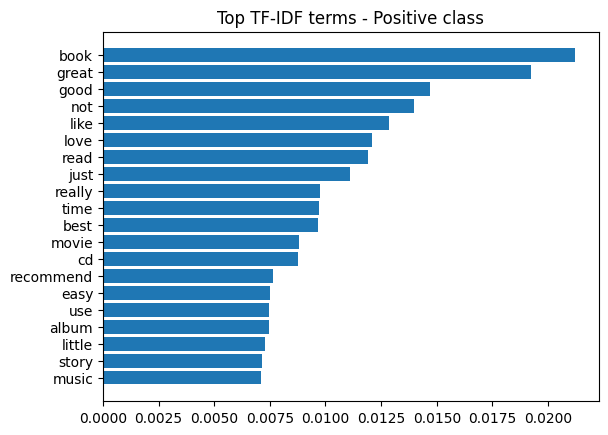

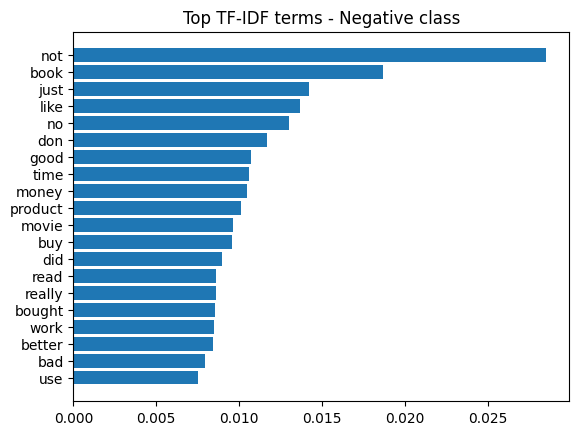

In [43]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = np.array(tfidf.get_feature_names_out())

# odvoji dokumente po klasama
X_pos = X_train[y_train == 1]
X_neg = X_train[y_train == 0]

# srednja TF-IDF vrednost po klasi
mean_tfidf_pos = np.asarray(X_pos.mean(axis=0)).ravel()
mean_tfidf_neg = np.asarray(X_neg.mean(axis=0)).ravel()

# top 20 reči
top_pos_idx = mean_tfidf_pos.argsort()[-20:]
top_neg_idx = mean_tfidf_neg.argsort()[-20:]

plt.figure()
plt.barh(feature_names[top_pos_idx], mean_tfidf_pos[top_pos_idx])
plt.title("Top TF-IDF terms - Positive class")
plt.show()

plt.figure()
plt.barh(feature_names[top_neg_idx], mean_tfidf_neg[top_neg_idx])
plt.title("Top TF-IDF terms - Negative class")
plt.show()

# Logistic Regression

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import time

lr = LogisticRegression(max_iter=2000)

start = time.time()
lr.fit(X_train, y_train)
train_time_lr = time.time() - start

start = time.time()
y_pred_lr = lr.predict(X_test)
test_time_lr = time.time() - start

print("Train time:", round(train_time_lr,2), "s")
print("Test time:", round(test_time_lr,2), "s")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Macro F1:", f1_score(y_test, y_pred_lr, average="macro"))

print("\nClassification report:")
print(classification_report(y_test, y_pred_lr))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Train time: 5.14 s
Test time: 0.01 s
Accuracy: 0.8963684210526316
Macro F1: 0.891255185660602

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87     15200
           1       0.90      0.93      0.91     22800

    accuracy                           0.90     38000
   macro avg       0.89      0.89      0.89     38000
weighted avg       0.90      0.90      0.90     38000

Confusion matrix:
[[12911  2289]
 [ 1649 21151]]


In [45]:
import numpy as np

feature_names = tfidf.get_feature_names_out()
coefs = lr.coef_[0]

top_pos = np.argsort(coefs)[-20:]
top_neg = np.argsort(coefs)[:20]

print("Top positive words:")
print(feature_names[top_pos])

print("\nTop negative words:")
print(feature_names[top_neg])

Top positive words:
['wonderful' 'loves' 'favorite' 'fantastic' 'superb' 'happy' 'no problems'
 'helps' 'amazing' 'awesome' 'pleased' 'love' 'easy' 'complaint' 'perfect'
 'best' 'won disappointed' 'excellent' 'great' 'not disappointed']

Top negative words:
['not worth' 'not recommend' 'disappointed' 'worst' 'disappointing'
 'disappointment' 'poorly' 'boring' 'waste' 'useless' 'not buy' 'not'
 'awful' 'terrible' 'not happy' 'mediocre' 'horrible' 'poor' 'returned'
 'worthless']


# Linear SVM

In [46]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import time

svm = LinearSVC()

start = time.time()
svm.fit(X_train, y_train)
train_time_svm = time.time() - start

start = time.time()
y_pred_svm = svm.predict(X_test)
test_time_svm = time.time() - start

print("Train time:", round(train_time_svm,2), "s")
print("Test time:", round(test_time_svm,2), "s")

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Macro F1:", f1_score(y_test, y_pred_svm, average="macro"))

print("\nClassification report:")
print(classification_report(y_test, y_pred_svm))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Train time: 14.73 s
Test time: 0.01 s
Accuracy: 0.8943947368421052
Macro F1: 0.889498382547375

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.87     15200
           1       0.90      0.92      0.91     22800

    accuracy                           0.89     38000
   macro avg       0.89      0.89      0.89     38000
weighted avg       0.89      0.89      0.89     38000

Confusion matrix:
[[12994  2206]
 [ 1807 20993]]


In [47]:
import numpy as np

feature_names = tfidf.get_feature_names_out()
coefs = svm.coef_[0]

top_pos = np.argsort(coefs)[-20:]
top_neg = np.argsort(coefs)[:20]

print("Top positive words:")
print(feature_names[top_pos])

print("\nTop negative words:")
print(feature_names[top_neg])

Top positive words:
['refreshing' 'pleased' 'wont disappointed' 'not boring' 'best'
 'not regret' 'won regret' 'perfect' 'downside' 'never fails' 'won sorry'
 'better expected' 'not dissapointed' 'never boring' 'complaint'
 'excellent' 'wasn disappointed' 'great' 'won disappointed'
 'not disappointed']

Top negative words:
['not worth' 'not recommend' 'disappointed' 'worst' 'disappointing'
 'boring' 'not impressed' 'waste' 'poorly' 'uninspired' 'don recommend'
 'isn worth' 'disappointment' 'wouldn recommend' 'not buy' 'worthless'
 'useless' 'not happy' 'stay away' 'terrible']


# Naive Bayes

In [48]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import time

nb = MultinomialNB(alpha=1.0)  # alpha = Laplace smoothing

start = time.time()
nb.fit(X_train, y_train)
train_time_nb = time.time() - start

start = time.time()
y_pred_nb = nb.predict(X_test)
test_time_nb = time.time() - start

print("Train time:", round(train_time_nb,2), "s")
print("Test time:", round(test_time_nb,2), "s")

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Macro F1:", f1_score(y_test, y_pred_nb, average="macro"))

print("\nClassification report:")
print(classification_report(y_test, y_pred_nb))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_nb))

Train time: 0.24 s
Test time: 0.01 s
Accuracy: 0.8631052631578947
Macro F1: 0.8551147220857092

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82     15200
           1       0.86      0.91      0.89     22800

    accuracy                           0.86     38000
   macro avg       0.86      0.85      0.86     38000
weighted avg       0.86      0.86      0.86     38000

Confusion matrix:
[[11937  3263]
 [ 1939 20861]]


# Passive-Aggressive Classifier

In [49]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import time

pa = SGDClassifier(
    loss="hinge",        # isto kao linear SVM / passive aggressive
    penalty=None,
    learning_rate="pa1",
    eta0=1.0,
    max_iter=2000,
    random_state=42
)

start = time.time()
pa.fit(X_train, y_train)
train_time_pa = time.time() - start

start = time.time()
y_pred_pa = pa.predict(X_test)
test_time_pa = time.time() - start

print("Train time:", round(train_time_pa,2), "s")
print("Test time:", round(test_time_pa,2), "s")

print("Accuracy:", accuracy_score(y_test, y_pred_pa))
print("Macro F1:", f1_score(y_test, y_pred_pa, average="macro"))

print("\nClassification report:")
print(classification_report(y_test, y_pred_pa))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_pa))

Train time: 7.5 s
Test time: 0.0 s
Accuracy: 0.8649473684210527
Macro F1: 0.8596538296679841

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.84      0.83     15200
           1       0.89      0.88      0.89     22800

    accuracy                           0.86     38000
   macro avg       0.86      0.86      0.86     38000
weighted avg       0.87      0.86      0.87     38000

Confusion matrix:
[[12744  2456]
 [ 2676 20124]]


# Confusion Matrix

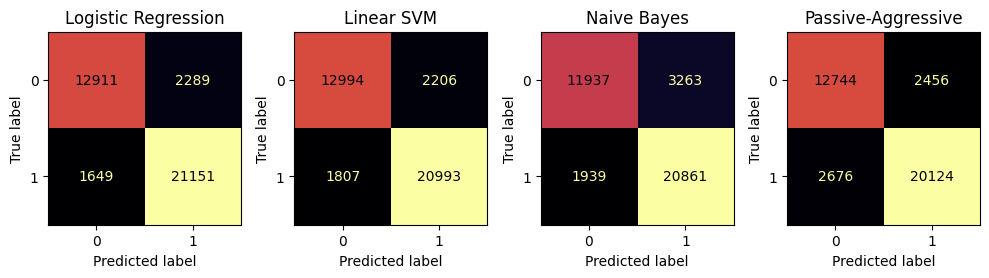

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# figure sa 3 matrice
fig, axes = plt.subplots(1, 4, figsize=(10,5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0], colorbar=False, values_format='d', cmap="inferno")
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, ax=axes[1], colorbar=False, values_format='d', cmap="inferno")
axes[1].set_title("Linear SVM")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb, ax=axes[2], colorbar=False, values_format='d', cmap="inferno")
axes[2].set_title("Naive Bayes")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_pa, ax=axes[3], colorbar=False, values_format='d', cmap="inferno")
axes[3].set_title("Passive-Aggressive")

plt.tight_layout()
plt.show()

# Word cloud

## Linear Regression

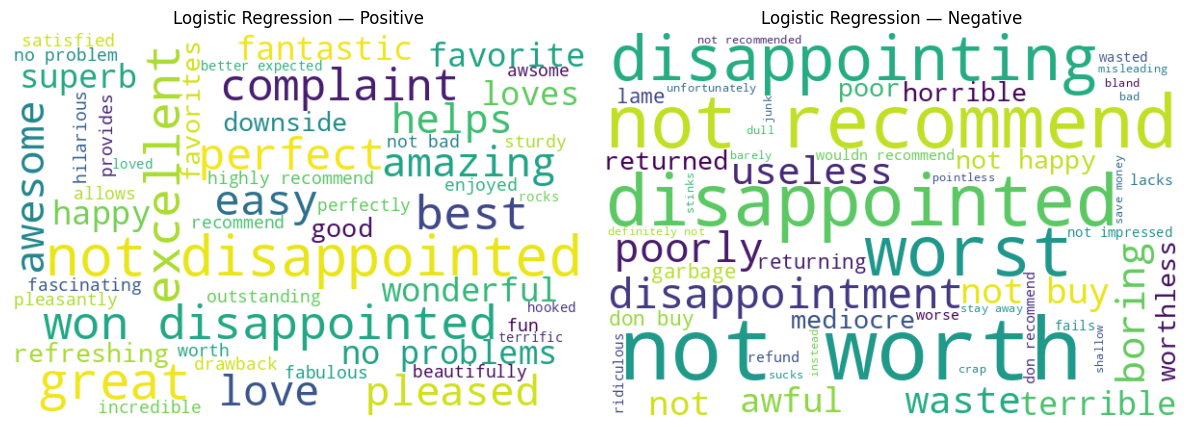

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

feature_names = tfidf.get_feature_names_out()

def wc_linear_side_by_side(model, feature_names, model_name, top_n=50):
    w = model.coef_.ravel()

    pos_idx = np.argsort(w)[-top_n:]
    neg_idx = np.argsort(w)[:top_n]

    pos_freq = {feature_names[i]: float(w[i]) for i in pos_idx if w[i] > 0}
    neg_freq = {feature_names[i]: float(-w[i]) for i in neg_idx if w[i] < 0}

    wc_pos = WordCloud(width=600, height=400, background_color="white",
                       collocations=False).generate_from_frequencies(pos_freq)

    wc_neg = WordCloud(width=600, height=400, background_color="white",
                       collocations=False).generate_from_frequencies(neg_freq)

    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    axes[0].imshow(wc_pos, interpolation="bilinear")
    axes[0].set_title(f"{model_name} — Positive")
    axes[0].axis("off")

    axes[1].imshow(wc_neg, interpolation="bilinear")
    axes[1].set_title(f"{model_name} — Negative")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# LR
wc_linear_side_by_side(lr, feature_names, "Logistic Regression")

## Linear SVM

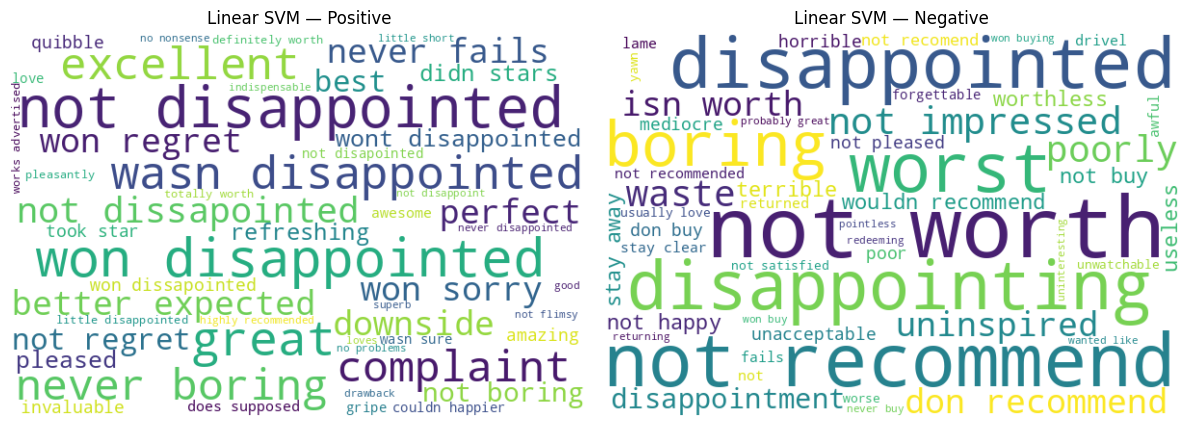

In [52]:
wc_linear_side_by_side(svm, feature_names, "Linear SVM")

## Naive Bayes

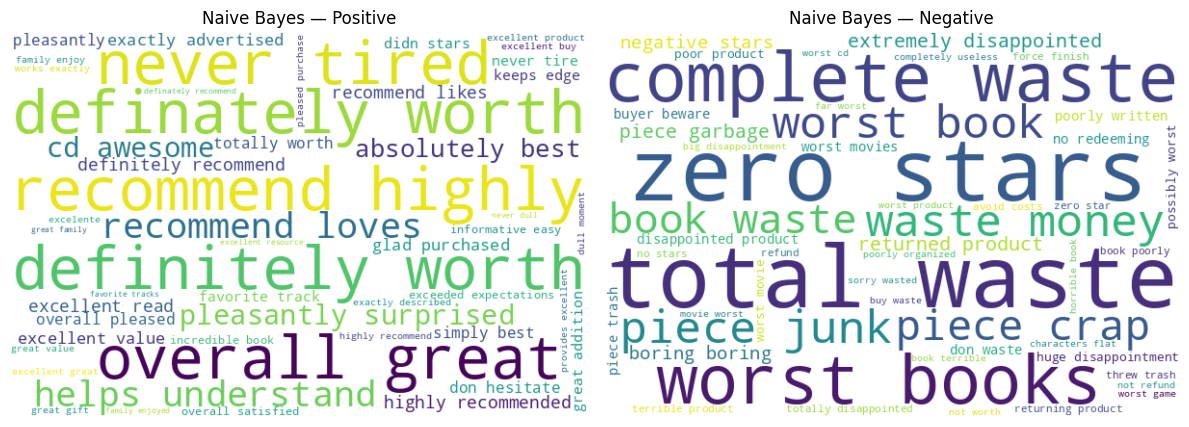

In [53]:
def wc_nb_side_by_side(nb, feature_names, model_name="Naive Bayes", top_n=50):
    diff = nb.feature_log_prob_[1] - nb.feature_log_prob_[0]

    pos_idx = np.argsort(diff)[-top_n:]
    neg_idx = np.argsort(diff)[:top_n]

    pos_freq = {feature_names[i]: float(diff[i]) for i in pos_idx if diff[i] > 0}
    neg_freq = {feature_names[i]: float(-diff[i]) for i in neg_idx if diff[i] < 0}

    wc_pos = WordCloud(width=600, height=400, background_color="white",
                       collocations=False).generate_from_frequencies(pos_freq)

    wc_neg = WordCloud(width=600, height=400, background_color="white",
                       collocations=False).generate_from_frequencies(neg_freq)

    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    axes[0].imshow(wc_pos, interpolation="bilinear")
    axes[0].set_title(f"{model_name} — Positive")
    axes[0].axis("off")

    axes[1].imshow(wc_neg, interpolation="bilinear")
    axes[1].set_title(f"{model_name} — Negative")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

wc_nb_side_by_side(nb, feature_names)

## Passive-Aggressive Classifier

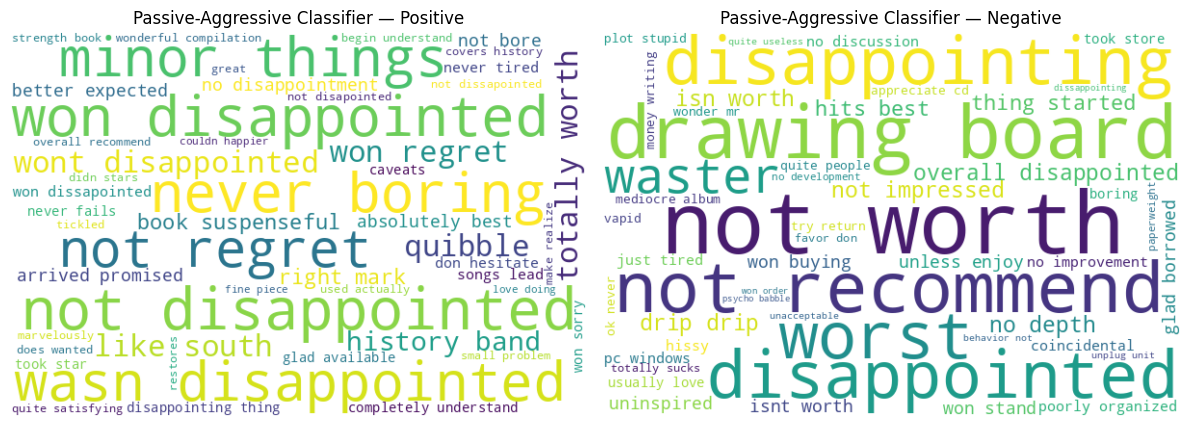

In [54]:
wc_linear_side_by_side(pa, feature_names, "Passive-Aggressive Classifier")

# Comparison

In [55]:
from sklearn.metrics import accuracy_score

print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred_lr))
print("Linear SVM accuracy:", accuracy_score(y_test, y_pred_svm))
print("Naive Bayes accuracy:", accuracy_score(y_test, y_pred_nb))
print("Passive-Aggressive accuracy:", accuracy_score(y_test, y_pred_pa))

Logistic Regression accuracy: 0.8963684210526316
Linear SVM accuracy: 0.8943947368421052
Naive Bayes accuracy: 0.8631052631578947
Passive-Aggressive accuracy: 0.8649473684210527


# Yelp reviews

In [56]:
df_test_ylp = pd.read_csv('yelp_reviews/test.csv')

## Preprocessing

In [57]:
df_test_ylp["text_clean"]  = df_test_ylp["text"].map(preprocess_text)
y_test_ylp  = df_test_ylp["label"].astype(int).values

X_test_ylp_on_amz = tfidf.transform(df_test_ylp["text_clean"])

## Linear Regression

In [58]:
y_pred = lr.predict(X_test_ylp_on_amz)

print("Amazon→Yelp Accuracy:", accuracy_score(y_test_ylp, y_pred))
print("Amazon→Yelp Macro F1:", f1_score(y_test_ylp, y_pred, average="macro"))

print("\nClassification report:")
print(classification_report(y_test_ylp, y_pred))

print("Confusion matrix:")
print(confusion_matrix(y_test_ylp, y_pred))

Amazon→Yelp Accuracy: 0.8881052631578947
Amazon→Yelp Macro F1: 0.8875600918782748

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.82      0.88     19000
           1       0.84      0.96      0.90     19000

    accuracy                           0.89     38000
   macro avg       0.90      0.89      0.89     38000
weighted avg       0.90      0.89      0.89     38000

Confusion matrix:
[[15551  3449]
 [  803 18197]]


## Linear SVM

In [59]:
y_pred = svm.predict(X_test_ylp_on_amz)

print("Amazon→Yelp Accuracy:", accuracy_score(y_test_ylp, y_pred))
print("Amazon→Yelp Macro F1:", f1_score(y_test_ylp, y_pred, average="macro"))

print("\nClassification report:")
print(classification_report(y_test_ylp, y_pred))

print("Confusion matrix:")
print(confusion_matrix(y_test_ylp, y_pred))

Amazon→Yelp Accuracy: 0.8790789473684211
Amazon→Yelp Macro F1: 0.8784821661332434

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.81      0.87     19000
           1       0.83      0.95      0.89     19000

    accuracy                           0.88     38000
   macro avg       0.89      0.88      0.88     38000
weighted avg       0.89      0.88      0.88     38000

Confusion matrix:
[[15371  3629]
 [  966 18034]]


## Naive Bayes

In [60]:
y_pred = nb.predict(X_test_ylp_on_amz)

print("Amazon→Yelp Accuracy:", accuracy_score(y_test_ylp, y_pred))
print("Amazon→Yelp Macro F1:", f1_score(y_test_ylp, y_pred, average="macro"))

print("\nClassification report:")
print(classification_report(y_test_ylp, y_pred))

print("Confusion matrix:")
print(confusion_matrix(y_test_ylp, y_pred))

Amazon→Yelp Accuracy: 0.8557105263157895
Amazon→Yelp Macro F1: 0.8542922978536184

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.76      0.84     19000
           1       0.80      0.95      0.87     19000

    accuracy                           0.86     38000
   macro avg       0.87      0.86      0.85     38000
weighted avg       0.87      0.86      0.85     38000

Confusion matrix:
[[14384  4616]
 [  867 18133]]


## Passive-Aggressive Classifier

In [61]:
y_pred = pa.predict(X_test_ylp_on_amz)

print("Amazon→Yelp Accuracy:", accuracy_score(y_test_ylp, y_pred))
print("Amazon→Yelp Macro F1:", f1_score(y_test_ylp, y_pred, average="macro"))

print("\nClassification report:")
print(classification_report(y_test_ylp, y_pred))

print("Confusion matrix:")
print(confusion_matrix(y_test_ylp, y_pred))

Amazon→Yelp Accuracy: 0.8485526315789473
Amazon→Yelp Macro F1: 0.8478096999795

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.78      0.84     19000
           1       0.81      0.92      0.86     19000

    accuracy                           0.85     38000
   macro avg       0.86      0.85      0.85     38000
weighted avg       0.86      0.85      0.85     38000

Confusion matrix:
[[14795  4205]
 [ 1550 17450]]


## Confusion matrix

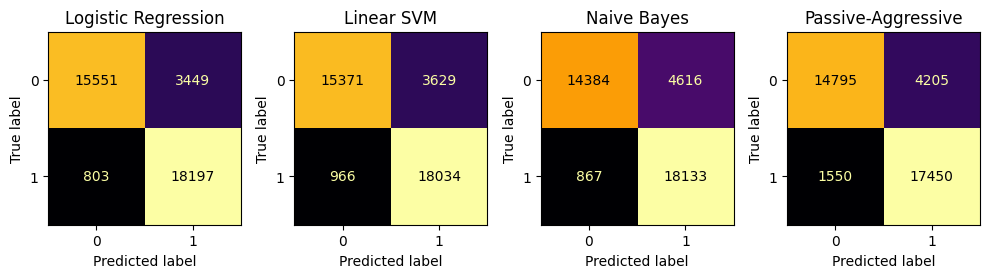

In [62]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# predikcije (ako već nisu napravljene)
y_pred_ylp_lr  = lr.predict(X_test_ylp_on_amz)
y_pred_ylp_svm = svm.predict(X_test_ylp_on_amz)
y_pred_ylp_nb  = nb.predict(X_test_ylp_on_amz)
y_pred_ylp_pa  = pa.predict(X_test_ylp_on_amz)

# figure sa 3 matrice
fig, axes = plt.subplots(1, 4, figsize=(10,5))

ConfusionMatrixDisplay.from_predictions(y_test_ylp, y_pred_ylp_lr, ax=axes[0], colorbar=False, values_format='d', cmap="inferno")
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test_ylp, y_pred_ylp_svm, ax=axes[1], colorbar=False, values_format='d', cmap="inferno")
axes[1].set_title("Linear SVM")

ConfusionMatrixDisplay.from_predictions(y_test_ylp, y_pred_ylp_nb, ax=axes[2], colorbar=False, values_format='d', cmap="inferno")
axes[2].set_title("Naive Bayes")

ConfusionMatrixDisplay.from_predictions(y_test_ylp, y_pred_ylp_pa, ax=axes[3], colorbar=False, values_format='d', cmap="inferno")
axes[3].set_title("Passive-Aggressive")

plt.tight_layout()
plt.show()

## Comparison

In [63]:
from sklearn.metrics import accuracy_score

print("Logistic Regression accuracy:", accuracy_score(y_test_ylp, y_pred_ylp_lr))
print("Linear SVM accuracy:", accuracy_score(y_test_ylp, y_pred_ylp_svm))
print("Naive Bayes accuracy:", accuracy_score(y_test_ylp, y_pred_ylp_nb))
print("Passive-Aggressive accuracy:", accuracy_score(y_test_ylp, y_pred_ylp_pa))

Logistic Regression accuracy: 0.8881052631578947
Linear SVM accuracy: 0.8790789473684211
Naive Bayes accuracy: 0.8557105263157895
Passive-Aggressive accuracy: 0.8485526315789473
